## 1. Mount Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Define Paths

In [2]:
BASE_PATH = "/content/drive/MyDrive/job-posting-classifier"

DATA_PROCESSED = BASE_PATH + "/data/processed/cleaned_data.csv"
SVM_MODEL_PATH = BASE_PATH + "/models/svm_model.pkl"
TFIDF_PATH = BASE_PATH + "/models/tfidf_vectorizer.pkl"
BERT_MODEL_PATH = BASE_PATH + "/models/distilbert_model"

## 3. Define Paths

In [3]:
!pip install shap

## 4. Import Libraries

In [4]:
import shap
import joblib
import torch
import numpy as np
import pandas as pd

from transformers import AutoTokenizer, AutoModelForSequenceClassification

## 1. Explain SGD Model

### 1.1 Load Data and Models


In [5]:
df = pd.read_csv(DATA_PROCESSED)
X = df["text"]

svm_model = joblib.load(SVM_MODEL_PATH)
tfidf = joblib.load(TFIDF_PATH)

print("SVM + TFIDF loaded")

SVM + TFIDF loaded


### 1.2 Create SHAP Explainer

In [6]:
svm_explainer = shap.LinearExplainer(
    svm_model,
    tfidf.transform(X[:100])
)

### 1.3 Explain Sample

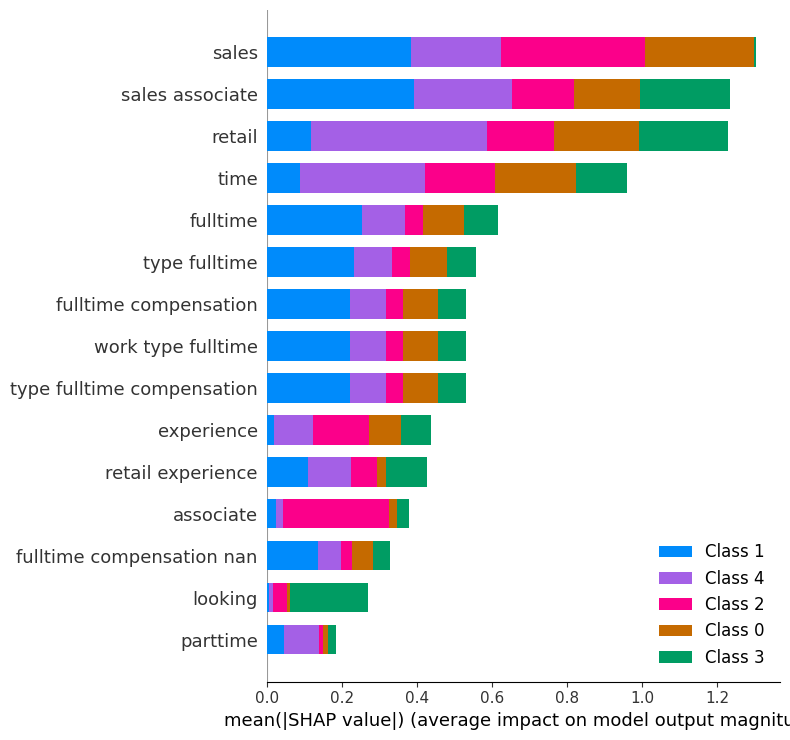

In [7]:
sample_text = "Looking for a part-time sales associate with retail experience"

# Transform text
sample_vec = tfidf.transform([sample_text])

# SHAP values
shap_values = svm_explainer(sample_vec)

# IMPORTANT FIX
shap.summary_plot(
    shap_values,
    sample_vec,
    feature_names=tfidf.get_feature_names_out(),
    max_display=15
)

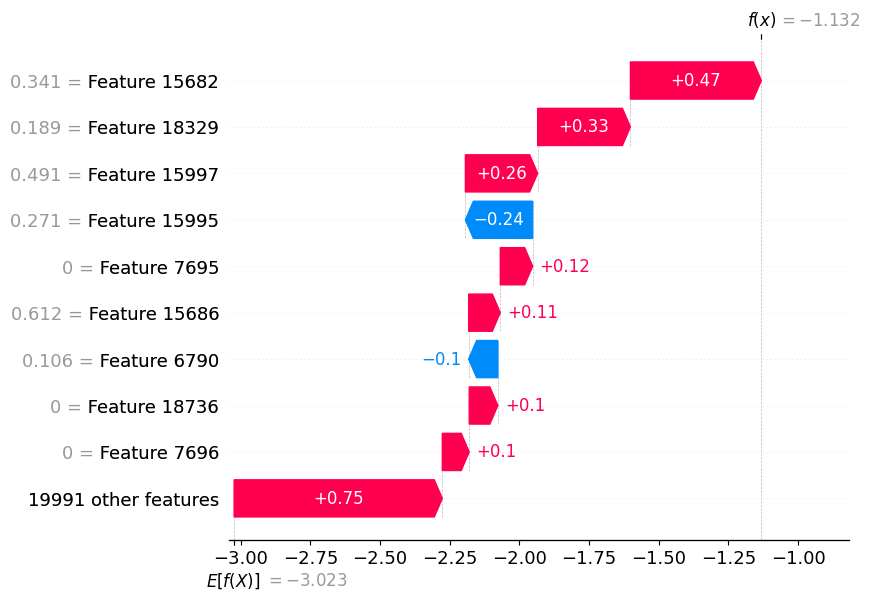

In [8]:
sample_text = "Looking for a part-time sales associate with retail experience"

sample_vec = tfidf.transform([sample_text])

shap_values = svm_explainer(sample_vec)

pred_class = np.argmax(svm_model.predict_proba(sample_vec))

shap.plots.waterfall(shap_values[0, :, pred_class])

In [9]:
# print("\nTop important words (BERT):")

# # ✅ get fresh BERT shap values
# shap_values = bert_explainer([sample_text])

# pred_class = np.argmax(predict([sample_text]))

# tokens = shap_values.data[0]   # correct tokens
# values = shap_values.values[0][:, pred_class]

# # convert safely
# tokens = list(tokens)
# values = np.array(values)

# # sort top words
# top_indices = np.argsort(np.abs(values))[::-1][:10]

# for i in top_indices:
#     print(tokens[i], ":", round(values[i], 3))

## 2. BERT EXPLAINABILITY

### 2.1 Load BERT

In [10]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(BERT_MODEL_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
model.eval()

print("BERT loaded")

Loading weights:   0%|          | 0/106 [00:01<?, ?it/s]

BERT loaded


### 2.2 Prediction Function

In [11]:
def predict(texts):

    # ✅ FIX: ensure list of strings
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    texts = [str(t) for t in texts]

    inputs = tokenizer(
        texts,
        padding=True,
        truncation=True,
        max_length=128,
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)

    return outputs.logits.cpu().numpy()

### 2.3 SHAP Explainer

In [12]:
bert_explainer = shap.Explainer(predict, tokenizer)

### 2.4 Explain Text

In [13]:
sample_text = "Looking for a part-time sales associate with retail experience"

shap_values = bert_explainer([sample_text])

pred_class = np.argmax(predict([sample_text]))

classes = ["Contract", "Full-time", "Internship", "Other", "Part-time"]
print("Predicted class (BERT):", classes[pred_class])

shap.plots.text(shap_values[0, :, pred_class])

  0%|          | 0/110 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [00:25, 25.28s/it]               

Predicted class (BERT): Part-time


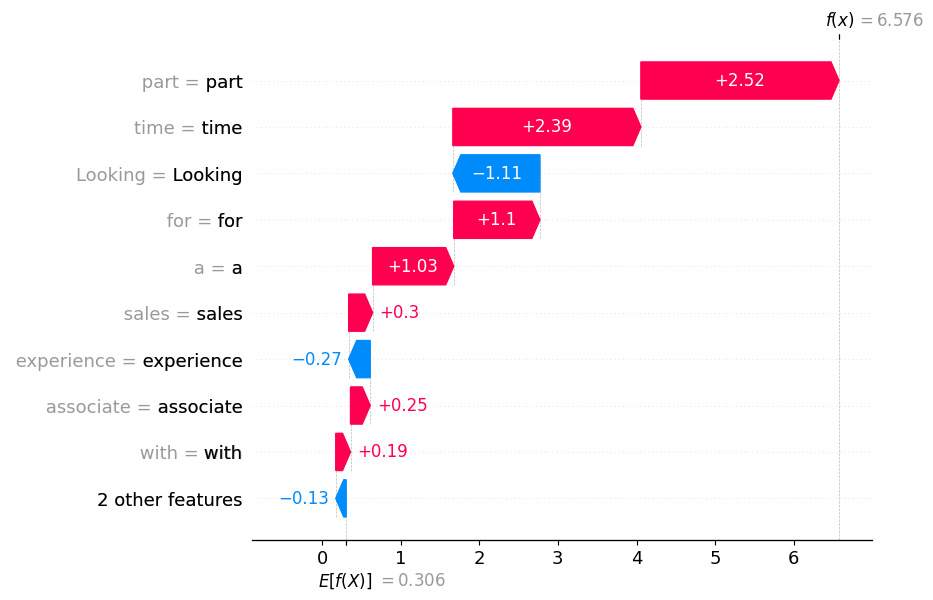

In [14]:
shap.plots.waterfall(shap_values[0, :, pred_class])

### 1. Load model.

In [15]:
# def full_prediction(text):

#     print("\n==============================")
#     print("INPUT:", text)
#     print("==============================")

#     # 🔹 Prediction
#     label, conf, top_preds = predict_job_type(text)

#     print("\n🔹 Prediction:", label)
#     print("🔹 Confidence:", round(conf, 3))

#     print("\n🔹 Top Predictions:")
#     for cls, prob in top_preds:
#         print(cls, ":", prob)

#     # 🔹 SVM Explanation
#     print("\n🔹 SVM Explanation (Keywords):")

#     sample_vec = tfidf.transform([text])
#     shap_values_svm = svm_explainer(sample_vec)

#     pred_class_svm = np.argmax(svm_model.predict_proba(sample_vec))

#     shap.plots.waterfall(shap_values_svm[0, :, pred_class_svm])

#     # 🔹 BERT Explanation
#     print("\n🔹 BERT Explanation (Context):")

#     shap_values_bert = bert_explainer([text])

#     pred_class_bert = np.argmax(predict([text]))

#     shap.plots.waterfall(shap_values_bert[0, :, pred_class_bert])

#     # 🔹 Top words (BERT)
#     print("\n🔹 Important Words (BERT):")

#     tokens = list(shap_values_bert.data[0])
#     values = np.array(shap_values_bert.values[0][:, pred_class_bert])

#     min_len = min(len(tokens), len(values))
#     tokens = tokens[:min_len]
#     values = values[:min_len]

#     top_indices = np.argsort(np.abs(values))[::-1][:10]

#     for i in top_indices:
#         print(tokens[i], ":", round(values[i], 3))

In [16]:
# full_prediction("Looking for a part-time retail sales associate for weekend shifts")


INPUT: Looking for a part-time retail sales associate for weekend shifts


NameError: name 'predict_job_type' is not defined

### 2. Create Prediction Function

In [ ]:
# import torch
# import numpy as np

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model.to(device)

# import torch
# import numpy as np

# device = "cuda" if torch.cuda.is_available() else "cpu"
# model.to(device)

# def predict(texts):

#     inputs = tokenizer(
#         texts,
#         padding=True,
#         truncation=True,
#         max_length=192,
#         return_tensors="pt"
#     ).to(device)

#     with torch.no_grad():
#         outputs = model(**inputs)

#     return outputs.logits.cpu().numpy()

### 2. Create SHAP Text Explainer

In [ ]:
# import shap

# masker = shap.maskers.Text(tokenizer)

# explainer = shap.Explainer(predict, masker)

### 3. Explain Text

In [ ]:
# sample_text = "Looking for a part-time sales associate with retail experience"

# shap_values = explainer([sample_text])

# shap.plots.text(shap_values[0])